# Geocalibration

This notebook explores the latest geocal processed data from Agisoft Metashape to understand how it differs from previous notebooks and how we can preform the fits for $R^r_{r'}$ and $R^m_c$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import itertools
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

from typing import List

In [9]:
data_fpath = "../plots/m41_site_cal_v230_v3_20240809_152305.xlsx"
f_str = "034"

to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_mat = lambda x:np.array([[float(val.strip()) for val in r[1:].split(", ") if len(val)] for r in x[1:-2].split("], ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_comma)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_comma)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_comma)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_comma)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
    """
    Form the H matrix from the ground truth data
    """
    h_r = data_["h_r_vec"][idx]
    v_r = data_["v_r_vec"][idx]
    a_r = data_["a_r_vec"][idx]

    H_r = np.array([h_r, v_r, a_r]).T

    return H_r

# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)

# drop the outliers
drop_idxs = [565, 568, 563, 564, 566, 567, 234, 151] # outliers based on fl-fmc plots
data_all.drop(axis=0, index=drop_idxs, inplace=True)
data_all.reset_index(inplace=True, drop=True)

# split into left and right camera
zl34, zr34 = get_zl_zr(f_str, data_all)

# Focal Length Fits

In [10]:
X_l, Y_l = np.vstack([np.ones(zl34.shape[0]), zl34["fmc"]]).T , zl34["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
print(f"[L] fl = {theta_l[0]:.5f} + {theta_l[1]:.5f} * fmc")

X_r, Y_r = np.vstack([np.ones(zr34.shape[0]), zr34["fmc"]]).T , zr34["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
print(f"[R] fl = {theta_r[0]:.5f} + {theta_r[1]:.5f} * fmc")

[L] fl = 4687.11755 + 0.04762 * fmc
[R] fl = 4694.16181 + 0.04853 * fmc


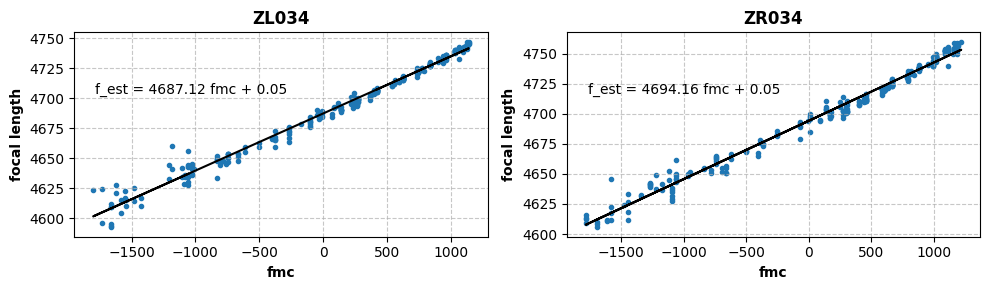

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
f_str = "034"

# ZL034 FL-FMC plots
ax[0].scatter(zl34["fmc"], zl34["f_est"], marker='.')
ax[0].plot(zl34["fmc"], [theta_l[0] + theta_l[1] * f for f in zl34["fmc"]],
        color="black")
ax[0].grid(linestyle="--", alpha=0.7)
ax[0].set_xlabel("fmc", fontweight="bold")
ax[0].set_ylabel("focal length", fontweight="bold")
ax[0].set_title(f"ZL034", fontweight="bold")
ax[0].text(0.05, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# ZR034 FL-FMC plots
ax[1].scatter(zr34["fmc"], zr34["f_est"], marker='.')
ax[1].plot(zr34["fmc"], [theta_r[0] + theta_r[1] * f for f in zr34["fmc"]],
        color="black")
ax[1].grid(linestyle="--", alpha=0.7)
ax[1].set_xlabel("fmc", fontweight="bold")
ax[1].set_ylabel("focal length", fontweight="bold")
ax[1].set_title(f"ZR034", fontweight="bold")
ax[1].text(0.05, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)

fig.tight_layout()

# Rotation Fitting

### Kabsch Fit

In [5]:
def solve_r_mc(data_, rot_rrp, fl0, fl1, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute scaled hm from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    hm = (R_rrp @ R_rpm).T @ hr 
    m_frame.append(lambda_h * hm[:,0])
    m_frame.append(lambda_v * hm[:,1])
    m_frame.append(lambda_a * hm[:,2])

    # compute hm from hc
    cam = data_["cam"].iloc[i][:2]
    fl = fl0 + fl1 * data_["fmc"][i]
    b1, b2, cx, cy = data_[["b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
    hc = np.array([[fl+b1, 0, 0],
                    [b2, fl, 0],
                    [cx, cy, 1]])
    c_frame.append(lambda_h * hc[:,0])
    c_frame.append(lambda_v * hc[:,1])
    c_frame.append(lambda_a * hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd

def solve_r_rrp(data_, rot_mc, fl0, fl1, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    r_frame.append(lambda_h * hr[:,0])
    r_frame.append(lambda_v * hr[:,1])
    r_frame.append(lambda_a * hr[:,2])

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    cam = data_["cam"].iloc[i][:2]
    fl = fl0 + fl1 * data_["fmc"][i]
    b1, b2, cx, cy = data_[["b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    hrp = R_rpm @ R_mc @ hc
    rp_frame.append(lambda_h * hrp[:,0])
    rp_frame.append(lambda_v * hrp[:,1])
    rp_frame.append(lambda_a * hrp[:,2])

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc, fl0, fl1):
  # convert rotations to matrices
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  # parse h,v,a vectors in r and c frame
  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    cam = data_["cam"].iloc[i][:2]
    fl = fl0 + fl1 * data_["fmc"][i]
    b1, b2, cx, cy = data_[["b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

def kabsch_fit(data_, fl0, fl1, lambda_h, lambda_v, lambda_a, verbosity, iterations=50, verbose=25, epsilon=1e-17):
  """
  Performs the iterative kabsch algorithm to find rot_rrp and rot_mc
  """

  # here we use the best lambdas to redo the fit and plot the results in Hr space
  rot_rrp_rssd = float('inf')
  rot_rrp = R.from_quat([0, 0, 0, 1])
  for i in range(iterations):
    rot_mc, rot_mc_rssd = solve_r_mc(data_, rot_rrp, fl0, fl1, lambda_h, lambda_v, lambda_a)
    rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data_, rot_mc, fl0, fl1, lambda_h, lambda_v, lambda_a)

    if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon and verbosity:
      print('-' * 150)
      print(f"Convergence critertia met at {i}")
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
      break

    rot_rrp_rssd = old_rot_rrp_rssd


    if ((i+1) % verbose == 0) and verbosity:
      print('-' * 150)
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
  
  return rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd

We first perform a hyperparameter tuning to find $\lambda_h$, $\lambda_v$ & $\lambda_a$ such that when Kabsch algorithm is runned on the sets $\{\lambda_h h^r_i, \lambda_v v^r_i, \lambda_a a^r_i\}$ and $\{\lambda_h h^c_i, \lambda_v v^c_i, \lambda_a a^c_i\}$, the sum of the relative errors for the $h$, $v$ and $a$ vectors are minimized.

In [ ]:
# search space 
lambda_hs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_vs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_as = [0.3, 0.9, 3, 9, 30, 90]

# # hyperparameter search for zl
# errs = []
# for lambda_h, lambda_v, lambda_a in itertools.product(lambda_hs, lambda_vs, lambda_as):
#     rot_rrp, rot_mc, _, _ = kabsch_fit(zl34, theta_l[0], theta_l[1], lambda_h, lambda_v, lambda_a, False) 
#     rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zl34, rot_rrp, rot_mc, theta_l[0], theta_l[1])
#     errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))

# sorted_errs = sorted(errs, key=lambda x:x[3])
# best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
# print(f"[ZL] lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}, rel_err:{best_rel_err:.4f}")
# hyper_params[f"ZL{f_str}"] = [best_lambda_h, best_lambda_v, best_lambda_a]

# # hyperparameter search for zr
# errs = []
# for lambda_h, lambda_v, lambda_a in itertools.product(lambda_hs, lambda_vs, lambda_as):
#     rot_rrp, rot_mc, _, _ = kabsch_fit(zr34, theta_r[0], theta_r[1], lambda_h, lambda_v, lambda_a, False)
#     rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zr34, rot_rrp, rot_mc, theta_r[0], theta_r[1])
#     errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))

# sorted_errs = sorted(errs, key=lambda x:x[3])
# best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
# print(f"[ZR] lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}, rel_err:{best_rel_err:.4f}")
# hyper_params[f"ZR{f_str}"] = [best_lambda_h, best_lambda_v, best_lambda_a]

f_strs = ["034"]
hyper_params = {
  "ZL026":[0.009, 0.009, 9], "ZR026":[0.09, 0.09, 90],
  "ZL034":[0.03, 0.09, 90], "ZR034":[0.003, 0.009, 9],
  "ZL048":[0.003, 0.009, 9], "ZR048":[0.03, 0.09, 90],
  "ZL063":[0.03, 0.09, 90], "ZR063":[0.003, 0.009, 9],
  "ZL079":[0.03, 0.09, 90], "ZR079":[0.03, 0.09, 90],
  "ZL100":[0.003, 0.003, 9], "ZR100":[0.003, 0.003, 9],
  "ZL110":[0.003, 0.003, 9], "ZR110":[0.003, 0.003, 9]
}

Here we look at how well the Iterative algorithm fits the $H^r$ parameters

In [18]:
lambda_h, lambda_v, lambda_a = 0.03, 0.009, 90

rot_rrp, rot_mc, _, _ = kabsch_fit(zl34, fl0=theta_l[0], fl1=theta_l[1], 
                            lambda_h=lambda_h, lambda_v=lambda_v, lambda_a=lambda_a,
                            verbosity=True)

------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:3.92842	 q_mc=[0.4912056654307561, 0.5048646049813149, 0.5060163960778372, 0.49777116407661287]
rot_rrp rssd:3.92837	 q_mc=[-3.663987118160939e-05, -2.805456330135142e-05, 0.0006135622536710437, 0.9999998107058932]
------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:3.92802	 q_mc=[0.49120897118001616, 0.5048618266535871, 0.505997773474267, 0.4977896502131778]
rot_rrp rssd:3.92802	 q_mc=[-3.7298428000924945e-05, -2.8507818836271852e-05, 0.0006385948493811457, 0.9999997949963538]


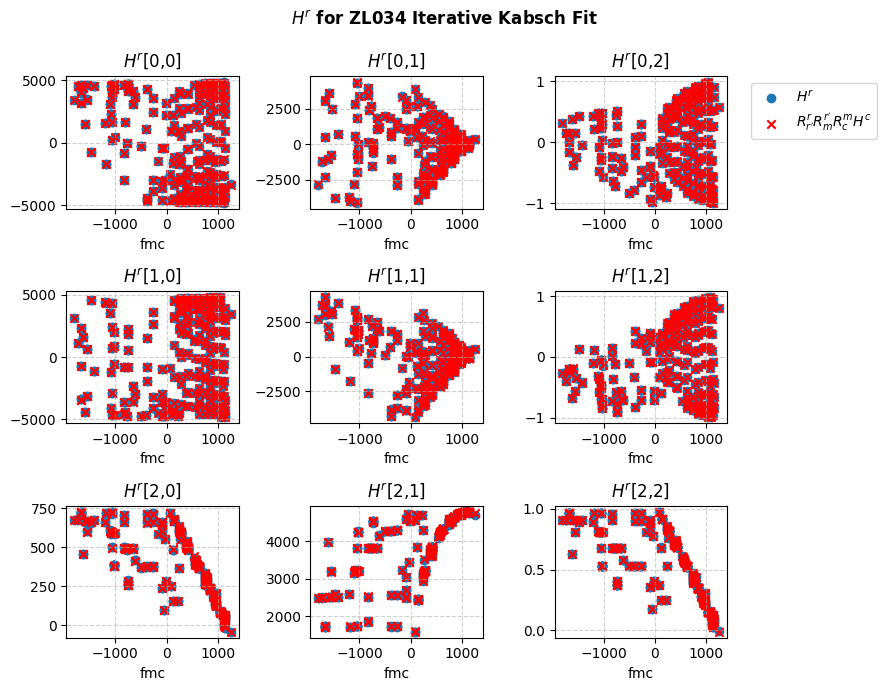

In [19]:
def plot_hr(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ plot", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

fig, ax = plot_hr(zl34, rot_rrp=rot_rrp, rot_mc=rot_mc, fl0=theta_l[0], fl1=theta_l[1])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

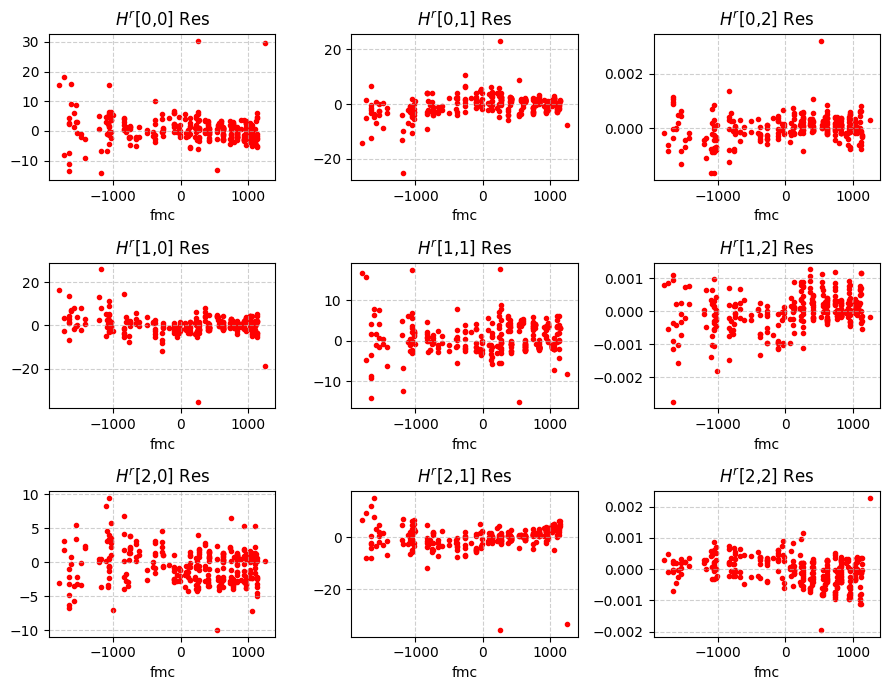

In [20]:
def plot_hr_res(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.tight_layout()

  return fig, ax

plot_hr_res(zl34, rot_rrp, rot_mc, theta_l[0], theta_l[1])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Next, we use the rotations that were found by the iterative kabsch algorithm as an initial guess for BFGS fits. 

In [31]:
def obj(x:List):
    R_rrp = R.from_quat(x[:4]).as_matrix()
    rot_mc_0 = R.from_quat(x[4:8])
    rot_mc_1 = R.from_quat(x[8:12])

    total_cost = 0
    for i in range(zl34.shape[0]):
        # H^r matrix
        Hr = get_H_r_data(i, zl34)

        # H^c matrix
        f, b1, b2, cx, cy = zl34[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
        cam = zl34["cam"].iloc[i]
        fl = theta_l[0] + theta_l[1] * f
        Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

        # rotation matrices
        R_rpm = get_R_rpm(i, zl34)
        
        R_mc = (rot_mc_0 * (rot_mc_1**(f/1000))).as_matrix()

        # Errors
        err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
        total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
        total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
        total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

    return total_cost/zl34.shape[0]

q_rrp_0 = list(rot_rrp.as_quat(canonical=True))
q_mc0_0 = list(rot_mc.as_quat(canonical=True))
x0 = q_rrp_0 + q_mc0_0 + [0,0,0,1]
res = minimize(obj, x0, method="BFGS",
                      options={"gtol":1e-6, "xrtol":1e-6, "maxiter":500})

q_rrp_zl = np.array(res.x[:4])/np.linalg.norm(res.x[:4])
q_mc_zl_0 = np.array(res.x[4:8])/np.linalg.norm(res.x[4:8])
q_mc_zl_1 = np.array(res.x[8:12])

print(f"Final function value:\t{res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:\t\t{q_rrp_zl}")
print(f"q_mc_zl_0:\t{list(q_mc_zl_0)}")
print(f"q_mc_zl_1:\t{list(q_mc_zl_1)}")
print("="*150)

Final function value:	0.000005
Final Jacobian value:	0.000018
q_rrp:		[-1.72535636e-05 -1.60344531e-05  5.35645481e-04  9.99999856e-01]
q_mc_zl_0:	[0.491194318113982, 0.5048575606990215, 0.5060847059993718, 0.49772005747317793]
q_mc_zl_1:	[0.00012471872808808197, -3.899382711979336e-05, -0.00011483797886846805, 1.0000000001941576]


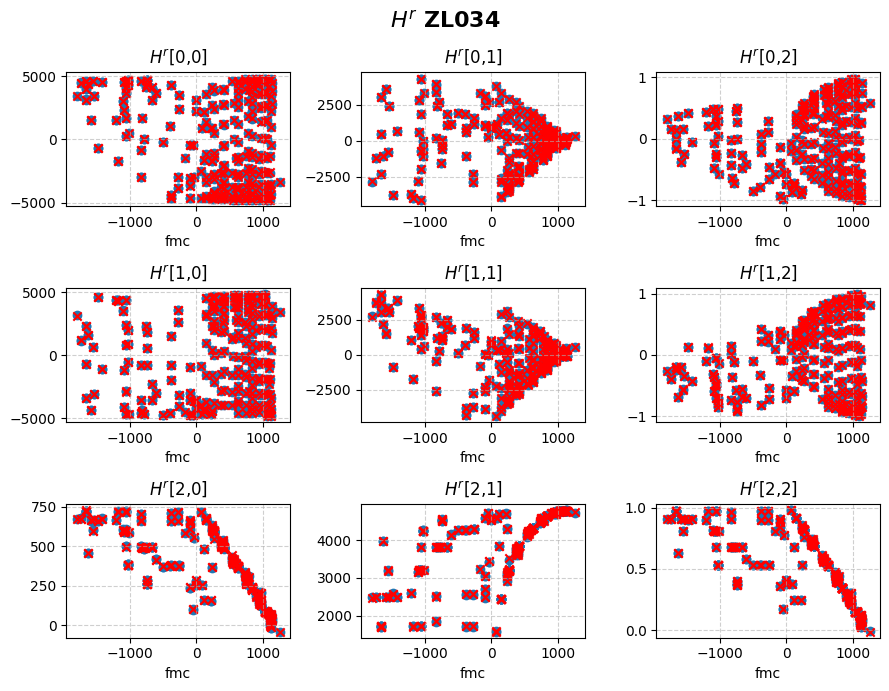

In [28]:
def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

fig, ax = plot_qmc_hr(zl34, q_rrp=q_rrp_zl, q_mc_0=q_mc_zl_0, q_mc_1=q_mc_zl_1,
    fl0=theta_l[0], fl1=theta_l[1])

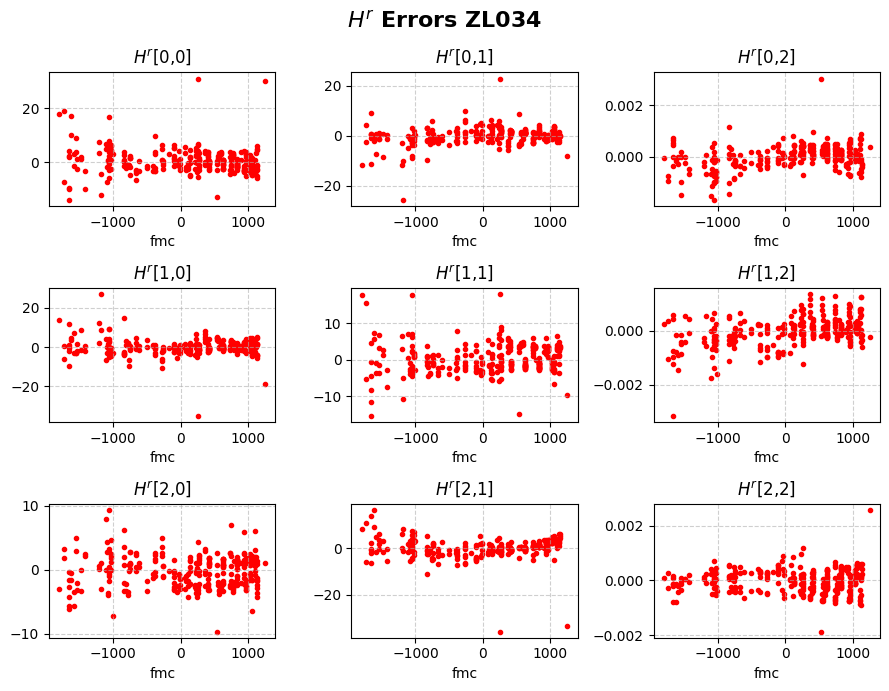

In [32]:
def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ Errors {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


fig, ax = plot_qmc_hr_err(zl34, q_rrp=q_rrp_0, q_mc_0=q_mc_zl_0, q_mc_1=q_mc_zl_1,
        fl0=theta_l[0], fl1=theta_l[1])